# XAI : eXplainable AI

Zeigt welche Wörter das RoBERTa Model am stärksten beeinflussen und falls ESG-relevante Begriffe wie "Management", "Diversity" und "Safety" prominent sind, stützt das die Aspektanalyse. \
Falls nur generische Sentiment-Wörter ("great", "terrible"), würde das die schwache Korrelation erklären.

1. Colab Laufzeit zu
T4 GPU ändern

In [1]:
!pip install transformers-interpret -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.3 MB/s eta 0:00:00


2. Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


3. Locate `amd_scored.csv`


In [3]:
#!ls -F '/content/drive/My Drive/'
!ls -F '/content/drive/My Drive/ESG Data/company_sentiment'


 02_sentiment_inference.ipynb
 amd_clean.csv
 amd_scored.csv
 amd_validation.csv
'Copy of XAI_eXplainable_AI_for_ESG_Sentiment.ipynb'
 dell_clean.csv
 dell_scored.csv
 dell_validation.csv
 hp_clean.csv
 hp_scored.csv
 hp_validation.csv
 nvidia_clean.csv
 nvidia_scored.csv
 nvidia_validation.csv
'Old scored'/
 results/
 XAI_eXplainable_AI_for_ESG_Sentiment.ipynb


In [4]:
from pathlib import Path
import pandas as pd

DRIVE_BASE = Path("/content/drive/MyDrive")
INPUT_DIR = DRIVE_BASE / "ESG Data/company_sentiment"
OUTPUT_DIR = DRIVE_BASE / "ESG Data/company_sentiment/results"

In [6]:
# ============================================================
# XAI — Explainable AI mit transformers-interpret
# ============================================================

from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers_interpret import SequenceClassificationExplainer
import pandas as pd
import numpy as np
from collections import Counter

# --- 7a: Modell und Explainer laden ---
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
explainer = SequenceClassificationExplainer(model, tokenizer)

# --- 7b: Stichprobe ziehen ---
# Lade alle Reviews (oder eine Firma zum Testen)
df = pd.read_csv(INPUT_DIR / "amd_scored.csv")
df = df[df["year"].between(2019, 2024)]

# 50 Reviews stratifiziert nach Sentiment
sample = pd.concat([
    df[df["sentiment_label"] == "positive"].sample(20, random_state=42),
    df[df["sentiment_label"] == "neutral"].sample(10, random_state=42),
    df[df["sentiment_label"] == "negative"].sample(20, random_state=42),
])
print(f"Stichprobe: {len(sample)} Reviews")

# --- 7c: Attributionen berechnen ---
all_attributions = []
top_positive_words = Counter()
top_negative_words = Counter()

for idx, row in sample.iterrows():
    text = str(row["review_text"])[:500]  # [:500] = Truncate für Speed

    try:
        word_attributions = explainer(text)
        attrs = explainer.word_attributions

        for word, score in attrs:
            if word in ["<s>", "</s>", "Ġ"] or len(word) < 3:
                continue
            clean_word = word.replace("Ġ", "").lower()
            if score > 0.05:
                top_positive_words[clean_word] += 1
            elif score < -0.05:
                top_negative_words[clean_word] += 1

            all_attributions.append({
                "review_idx": idx,
                "sentiment_label": row["sentiment_label"],
                "word": clean_word,
                "attribution": score
            })
    except Exception as e:
        print(f"  Fehler bei Review {idx}: {e}")
        continue

attrs_df = pd.DataFrame(all_attributions)

# --- 7d: Aggregierte Ergebnisse ---
print("\nTOP 20 POSITIV TREIBENDE WÖRTER:")
print("=" * 40)
for word, count in top_positive_words.most_common(20):
    mean_attr = attrs_df[attrs_df["word"] == word]["attribution"].mean()
    print(f"  {word:<20} {count:>4}x  "
          f"(Ø Attribution: {mean_attr:+.4f})")

print("\nTOP 20 NEGATIV TREIBENDE WÖRTER:")
print("=" * 40)
for word, count in top_negative_words.most_common(20):
    mean_attr = attrs_df[attrs_df["word"] == word]["attribution"].mean()
    print(f"  {word:<20} {count:>4}x  "
          f"(Ø Attribution: {mean_attr:+.4f})")

# --- 7e: ESG-Relevanz prüfen ---
esg_keywords = {
    "management", "leadership", "leader", "director",
    "diversity", "inclusion", "women", "gender",
    "safety", "injury", "hazard",
    "compensation", "salary", "pay", "bonus",
    "training", "development", "growth",
    "environment", "sustainability", "green",
    "ethics", "integrity", "compliance",
    "board", "governance", "transparency",
}

esg_relevant = attrs_df[attrs_df["word"].isin(esg_keywords)]
total_words = attrs_df["word"].nunique()
esg_words_found = esg_relevant["word"].nunique()

print(f"\n\nESG-RELEVANZ DER MODELL-ENTSCHEIDUNGEN:")
print(f"  Einzigartige Wörter gesamt: {total_words}")
print(f"  Davon ESG-relevant: {esg_words_found}")
print(f"  Anteil: {esg_words_found/total_words*100:.1f}%")

print(f"\n  ESG-relevante Wörter mit starker Attribution:")
for word in sorted(esg_keywords):
    word_data = attrs_df[attrs_df["word"] == word]
    if len(word_data) > 0:
        mean_a = word_data["attribution"].mean()
        count = len(word_data)
        direction = "POS" if mean_a > 0 else "NEG"
        print(f"    {word:<20} {count:>3}x  "
              f"Ø {mean_a:+.4f} ({direction})")

# --- 7f: Visualisierung eines Beispiels ---
# Einzelne Review visualisieren (für Screenshot/Export)
example_neg = sample[sample["sentiment_label"] == "negative"].iloc[0]
print(f"\n\nBEISPIEL-VISUALISIERUNG (negative Review):")
print(f"Text: {example_neg['review_text'][:200]}...")
print(f"Sterne: {example_neg['overall_stars']}")

word_attributions = explainer(str(example_neg["review_text"])[:500])
explainer.visualize(str(OUTPUT_DIR / "xai_beispiel_negativ.html"))

example_pos = sample[sample["sentiment_label"] == "positive"].iloc[0]
word_attributions = explainer(str(example_pos["review_text"])[:500])
explainer.visualize(str(OUTPUT_DIR / "xai_beispiel_positiv.html"))

print("\nVisualisierungen gespeichert als HTML in results/")

# --- 7g: Speichern ---
attrs_df.to_csv(OUTPUT_DIR / "xai_attributions.csv", index=False)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Stichprobe: 50 Reviews

TOP 20 POSITIV TREIBENDE WÖRTER:
  pros                   25x  (Ø Attribution: +0.0368)
  good                   21x  (Ø Attribution: +0.1502)
  work                   18x  (Ø Attribution: +0.0806)
  company                15x  (Ø Attribution: +0.1663)
  great                  14x  (Ø Attribution: +0.4650)
  culture                10x  (Ø Attribution: +0.1560)
  the                     8x  (Ø Attribution: +0.0256)
  and                     8x  (Ø Attribution: +0.0129)
  not                     7x  (Ø Attribution: +0.0542)
  very                    6x  (Ø Attribution: +0.1299)
  place                   6x  (Ø Attribution: +0.2155)
  cons                    6x  (Ø Attribution: -0.0181)
  bad                     6x  (Ø Attribution: +0.3799)
  management              6x  (Ø Attribution: +0.2317)
  balance                 6x  (Ø Attribution: +0.0603)
  environment             5x  (Ø Attribution: +0.1496)
  team                    5x  (Ø Attribution: +0.0905)
  lots  


Visualisierungen gespeichert als HTML in results/


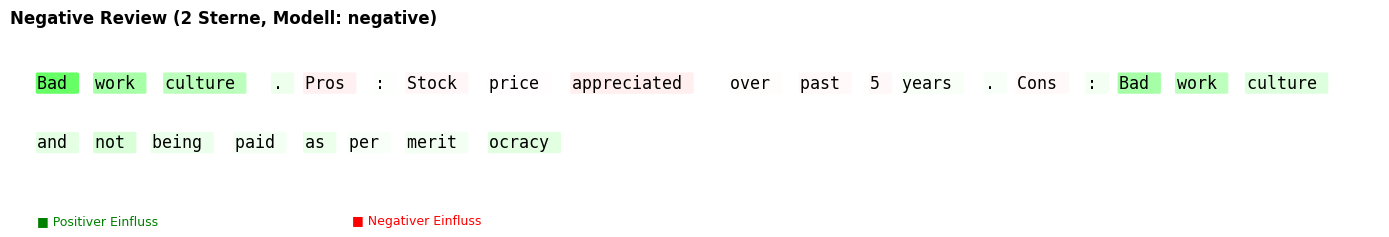

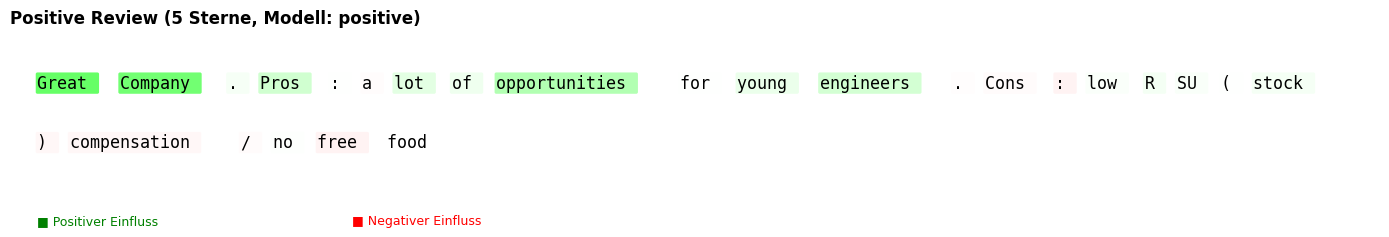

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_attribution(text, attributions, title, filename,
                     output_dir=OUTPUT_DIR):
    """Eigene XAI-Visualisierung mit intuitivem Farbschema:
       Grün = treibt Score positiv, Rot = treibt Score negativ"""

    words = [w for w, _ in attributions if w not in ["<s>", "</s>"]]
    scores = [s for w, s in attributions if w not in ["<s>", "</s>"]]

    # Wörter bereinigen (RoBERTa-Tokenizer-Artefakte)
    words = [w.replace("Ġ", " ").strip() for w in words]

    fig, ax = plt.subplots(figsize=(14, 2.5)) # Anpassung falls Wörter überlappen
    ax.axis("off")

    x_pos = 0.02
    y_pos = 0.7
    max_score = max(abs(s) for s in scores) if scores else 1

    for word, score in zip(words, scores):
        # Farbe: Grün für positiv, Rot für negativ
        if score > 0:
            intensity = min(score / max_score, 1.0)
            color = (1 - intensity * 0.6, 1, 1 - intensity * 0.6)
        else:
            intensity = min(abs(score) / max_score, 1.0)
            color = (1, 1 - intensity * 0.6, 1 - intensity * 0.6)

        txt = ax.text(x_pos, y_pos, word + " ",
                      fontsize=12, fontfamily="monospace",
                      transform=ax.transAxes,
                      bbox=dict(boxstyle="round,pad=0.1",
                               facecolor=color, edgecolor="none"))

        # Position für nächstes Wort berechnen
        renderer = fig.canvas.get_renderer()
        bbox = txt.get_window_extent(renderer=renderer)
        bbox_t = bbox.transformed(ax.transAxes.inverted())
        x_pos = bbox_t.x1 + 0.005

        if x_pos > 0.95:
            x_pos = 0.02
            y_pos -= 0.35

    ax.set_title(title, fontsize=12, fontweight="bold",
                 loc="left", pad=10)

    # Legende
    ax.text(0.02, -0.1, "■ Positiver Einfluss    ",
            color="green", fontsize=9, transform=ax.transAxes)
    ax.text(0.25, -0.1, "■ Negativer Einfluss",
            color="red", fontsize=9, transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}",
                dpi=300, bbox_inches="tight")
    plt.show()

# Für die negative Review:
word_attributions = explainer(str(example_neg["review_text"])[:500])
plot_attribution(
    example_neg["review_text"],
    explainer.word_attributions,
    f"Negative Review ({int(example_neg['overall_stars'])} Sterne, "
    f"Modell: {explainer.predicted_class_name})",
    "fig_xai_negativ.pdf"
)

# Für die positive Review:
word_attributions = explainer(str(example_pos["review_text"])[:500])
plot_attribution(
    example_pos["review_text"],
    explainer.word_attributions,
    f"Positive Review ({int(example_pos['overall_stars'])} Sterne, "
    f"Modell: {explainer.predicted_class_name})",
    "fig_xai_positiv.pdf"
)

Gespeichert: /content/drive/MyDrive/ESG Data/company_sentiment/results/fig_xai_negativ.pdf


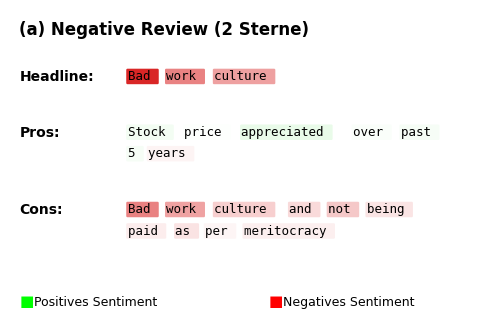

Gespeichert: /content/drive/MyDrive/ESG Data/company_sentiment/results/fig_xai_positiv.pdf


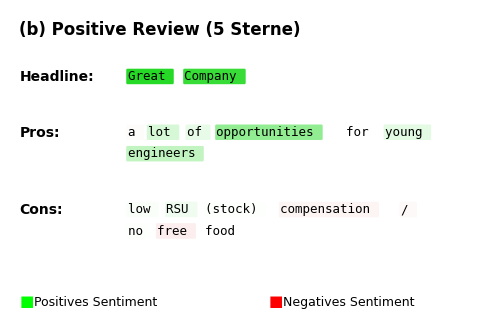

In [17]:
def plot_attribution(review_row, attributions, title, filepath,
                     predicted_class):
    """XAI-Visualisierung in 3 Zeilen: Headline, Pros, Cons"""

    # Attributionen bereinigen
    words = [w for w, _ in attributions if w not in ["<s>", "</s>"]]
    scores = [s for w, s in attributions if w not in ["<s>", "</s>"]]
    words = [w.replace("Ġ", " ").strip() for w in words]

    if predicted_class == "negative":
        scores = [-s for s in scores]

    # Word-Attribution-Mapping aufbauen
    word_scores = list(zip(words, scores))
    max_score = max(abs(s) for s in scores) if scores else 1

    # Texte aus der Review extrahieren
    headline = str(review_row.get("headline", ""))
    pros = str(review_row.get("pros", ""))
    cons = str(review_row.get("cons", ""))

    # Jede Zeile mit ihrem Label
    lines = [
        ("Headline:", headline),
        ("Pros:", pros),
        ("Cons:", cons),
    ]

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Titel
    ax.text(0.02, 0.95, title, fontsize=12, fontweight="bold",
            transform=ax.transAxes, va="top")

    y_pos = 0.72
    token_idx = 0  # Position im word_scores Array

    for label_text, line_text in lines:
        if not line_text.strip():
            continue

        # Label fett in schwarz
        ax.text(0.02, y_pos, label_text, fontsize=10,
                fontweight="bold", color="black",
                transform=ax.transAxes, va="top")
        x_pos = 0.25

        # Wörter der Zeile tokenisieren
        line_words = line_text.split()

        for word in line_words:
            # Passende Attribution finden
            color = (0.95, 0.95, 0.95)  # Default: hellgrau
            for i in range(token_idx, min(token_idx + 5, len(word_scores))):
                token, score = word_scores[i]
                if token.lower().strip() in word.lower() or \
                   word.lower() in token.lower().strip():
                    if score > 0:
                        intensity = min(score / max_score, 1.0)
                        color = (1 - intensity * 0.85,
                                 1 - intensity * 0.15,
                                 1 - intensity * 0.85)
                    else:
                        intensity = min(abs(score) / max_score, 1.0)
                        color = (1 - intensity * 0.15,
                                 1 - intensity * 0.85,
                                 1 - intensity * 0.85)
                    token_idx = i + 1
                    break

            # Wort kürzen falls zu lang
            display_word = word[:20] if len(word) > 20 else word

            txt = ax.text(x_pos, y_pos, display_word + " ",
                          fontsize=9, fontfamily="monospace",
                          transform=ax.transAxes, va="top",
                          bbox=dict(boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor="none"))

            renderer = fig.canvas.get_renderer()
            bbox = txt.get_window_extent(renderer=renderer)
            bbox_t = bbox.transformed(ax.transAxes.inverted())
            x_pos = bbox_t.x1 + 0.005

            # Zeilenumbruch innerhalb einer Zeile
            if x_pos > 0.85:
                x_pos = 0.25
                y_pos -= 0.10

        y_pos -= 0.26

    # ax.set_title('(a)', fontsize=14, fontweight="bold",
    #         loc="left", pad=8)

    # Legende
    y_pos -= 0.12
    ax.text(0.02, y_pos, "■",
            color="lime", fontsize=11, transform=ax.transAxes)
    ax.text(0.05, y_pos, "Positives Sentiment",
            color="black", fontsize=9, transform=ax.transAxes)
    ax.text(0.55, y_pos, "■", # Further adjusted x-position for the second square
            color="red", fontsize=11, transform=ax.transAxes)
    ax.text(0.58, y_pos, "Negatives Sentiment", # Further adjusted x-position for the second text
            color="black", fontsize=9, transform=ax.transAxes)

    # Unterkante abschneiden
    #ax.set_ylim(y_pos - 0.16, 1.0)

    plt.tight_layout()
    plt.savefig(str(filepath), dpi=300, bbox_inches="tight")
    print(f"Gespeichert: {filepath}")
    plt.show()


# === Aufrufe anpassen (review_row statt text) ===
word_attributions = explainer(str(example_neg["review_text"])[:500])
plot_attribution(
    example_neg,
    explainer.word_attributions,
    f"(a) Negative Review ({int(example_neg['overall_stars'])} Sterne)",
    OUTPUT_DIR / "fig_xai_negativ.pdf",
    predicted_class=explainer.predicted_class_name
)

word_attributions = explainer(str(example_pos["review_text"])[:500])
plot_attribution(
    example_pos,
    explainer.word_attributions,
    f"(b) Positive Review ({int(example_pos['overall_stars'])} Sterne)",
    OUTPUT_DIR / "fig_xai_positiv.pdf",
    predicted_class=explainer.predicted_class_name
)
